# Week 4 Day 2 — Probability & Distributions

## Objectives

- Calculate basic probabilities using a contingency table
- Understand the normal distribution and the 68-95-99.7 rule
- Simulate a binomial distribution using NumPy
- Demonstrate the Central Limit Theorem using sampling simulation

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.rcParams["figure.figsize"] = (10, 6)

# Load dataset
file_path = "../../Checkpoint-2/data/da_sales_transactions.csv"
df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print(f"Number of transactions: {len(df)}")
df.head()


Dataset loaded successfully.
Number of transactions: 1000


,Transaction_ID,Date,Customer_ID,Product_ID,Category,Units,Unit_Price,Discount_Pct,Channel,City,Return_Flag
0,T1,2025-01-24,C2,P2,Sports,5,539,15,Marketplace,Pune,1
1,T2,2025-12-15,C3,P3,Grocery,1,4228,5,Marketplace,Delhi,0
2,T3,2025-10-11,C4,P4,Books,2,2061,15,Offline,Chennai,0
3,T4,2025-04-24,C5,P5,Electronics,3,2164,0,Website,Chennai,0
4,T5,2025-06-25,C6,P6,Apparel,1,2341,0,Website,Kolkata,0


In [3]:
# Task 1: Basic Probabilities

# Event A: Transaction was returned
# Event B: Transaction was made through Website

returns = df["Return_Flag"] == 1
website = df["Channel"] == "Website"

# Calculate probabilities
p_A = returns.mean()
p_B = website.mean()
p_A_and_B = (returns & website).mean()
p_A_given_B = (returns & website).sum() / website.sum()

# Contingency table
contingency_table = pd.crosstab(
    df["Channel"],
    df["Return_Flag"]
)

print("Contingency Table:")
display(contingency_table)

print(f"P(A) - Probability of Return: {p_A:.4f}")
print(f"P(B) - Probability of Website: {p_B:.4f}")
print(f"P(A ∩ B) - Return AND Website: {p_A_and_B:.4f}")
print(f"P(A | B) - Return given Website: {p_A_given_B:.4f}")

Contingency Table:


Return_Flag,0,1
Channel,,
App,223,27
Marketplace,238,17
Offline,221,25
Website,221,28


P(A) - Probability of Return: 0.0970
P(B) - Probability of Website: 0.2490
P(A ∩ B) - Return AND Website: 0.0280
P(A | B) - Return given Website: 0.1124


## Task 2 — Normal Distribution

The normal distribution is a symmetric, bell-shaped probability distribution.

### 68-95-99.7 Rule

- About 68.27% of observations fall within ±1 standard deviation of the mean.
- About 95.45% fall within ±2 standard deviations.
- About 99.73% fall within ±3 standard deviations.

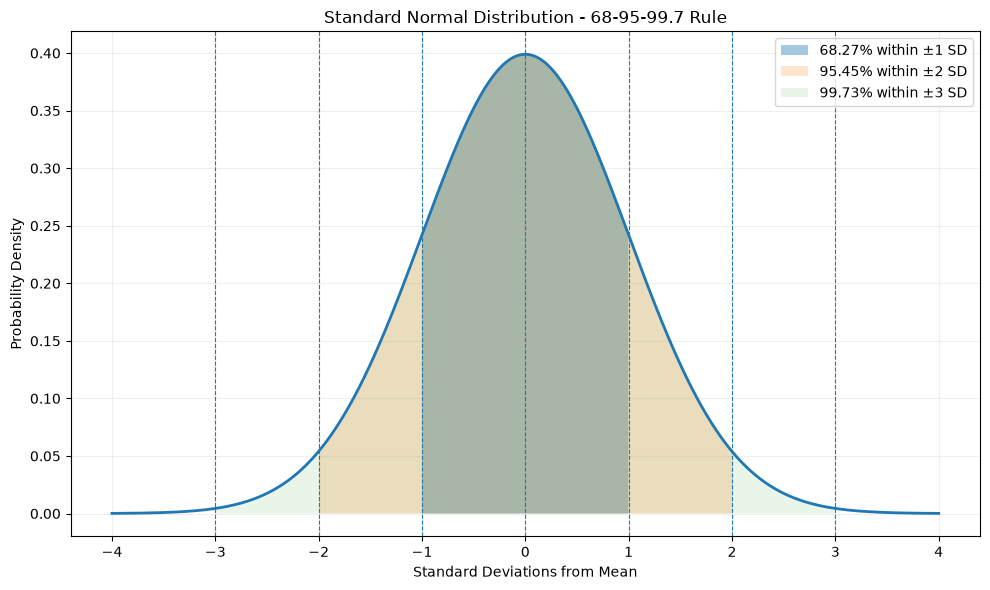

In [4]:
# Standard normal distribution

x = np.linspace(-4, 4, 1000)
y = norm.pdf(x, 0, 1)

plt.figure(figsize=(10, 6))
plt.plot(x, y, linewidth=2)

plt.fill_between(
    x, y,
    where=(x >= -1) & (x <= 1),
    alpha=0.4,
    label="68.27% within ±1 SD"
)

plt.fill_between(
    x, y,
    where=(x >= -2) & (x <= 2),
    alpha=0.2,
    label="95.45% within ±2 SD"
)

plt.fill_between(
    x, y,
    where=(x >= -3) & (x <= 3),
    alpha=0.1,
    label="99.73% within ±3 SD"
)

for value in [-3, -2, -1, 0, 1, 2, 3]:
    plt.axvline(value, linestyle="--", linewidth=0.8)

plt.title("Standard Normal Distribution - 68-95-99.7 Rule")
plt.xlabel("Standard Deviations from Mean")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## Task 3 — Binomial Distribution

A binomial distribution models the number of successes in a fixed number of independent trials, where each trial has two possible outcomes.

Here, we simulate 10 trials with a 50% probability of success and repeat the experiment 10,000 times.

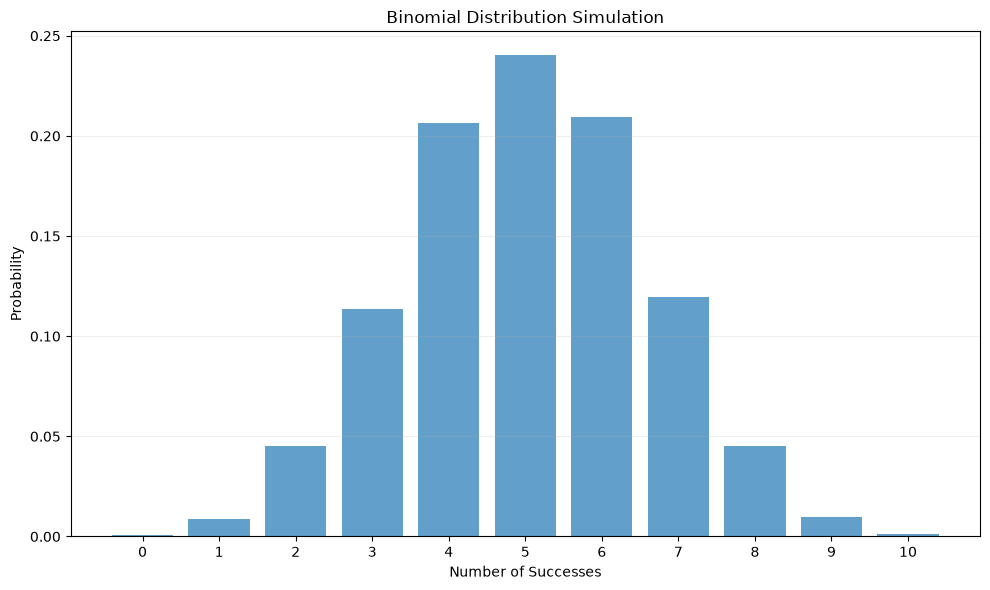

Number of trials (n): 10
Probability of success (p): 0.5
Number of simulations: 10000
Mean of simulated results: 5.0215
Standard deviation: 1.5841


In [5]:
# Binomial distribution simulation

n = 10
p = 0.5
simulations = 10000

binomial_results = np.random.binomial(
    n=n,
    p=p,
    size=simulations
)

values, counts = np.unique(
    binomial_results,
    return_counts=True
)

probabilities = counts / simulations

plt.figure(figsize=(10, 6))

plt.bar(
    values,
    probabilities,
    alpha=0.7
)

plt.title("Binomial Distribution Simulation")
plt.xlabel("Number of Successes")
plt.ylabel("Probability")
plt.xticks(range(n + 1))
plt.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

print(f"Number of trials (n): {n}")
print(f"Probability of success (p): {p}")
print(f"Number of simulations: {simulations}")
print(f"Mean of simulated results: {binomial_results.mean():.4f}")
print(f"Standard deviation: {binomial_results.std():.4f}")

## Task 4 — Central Limit Theorem

The Central Limit Theorem states that when many random samples are taken from a population, the distribution of their sample means tends to become approximately normal as the sample size increases.

In this simulation, we take 1,000 samples of 30 revenue values and examine the distribution of their sample means.

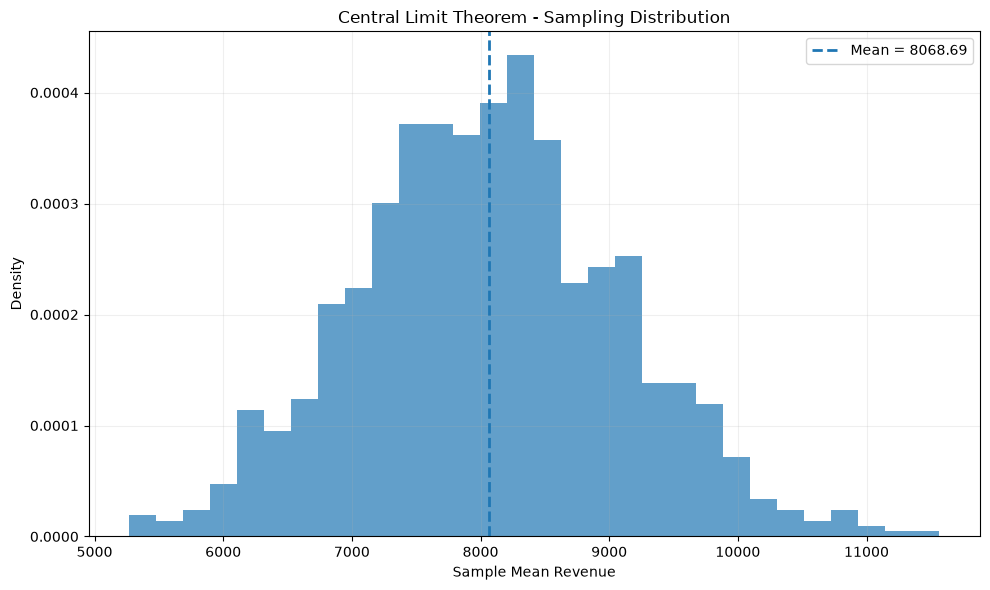

Population size: 1000
Sample size: 30
Number of samples: 1000
Mean of sample means: 8068.69
Standard deviation of sample means: 1021.40


In [6]:
# Central Limit Theorem simulation

# Calculate revenue
df["Revenue"] = (
    df["Units"]
    * df["Unit_Price"]
    * (1 - df["Discount_Pct"] / 100)
)

population = df["Revenue"].dropna()

sample_size = 30
number_of_samples = 1000

sample_means = []

for _ in range(number_of_samples):
    sample = np.random.choice(
        population,
        size=sample_size,
        replace=True
    )
    sample_means.append(sample.mean())

sample_means = np.array(sample_means)

plt.figure(figsize=(10, 6))

plt.hist(
    sample_means,
    bins=30,
    density=True,
    alpha=0.7
)

plt.axvline(
    sample_means.mean(),
    linestyle="--",
    linewidth=2,
    label=f"Mean = {sample_means.mean():.2f}"
)

plt.title("Central Limit Theorem - Sampling Distribution")
plt.xlabel("Sample Mean Revenue")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

print(f"Population size: {len(population)}")
print(f"Sample size: {sample_size}")
print(f"Number of samples: {number_of_samples}")
print(f"Mean of sample means: {sample_means.mean():.2f}")
print(f"Standard deviation of sample means: {sample_means.std():.2f}")

## Conclusion

- Basic probability was calculated using a contingency table.
- The normal distribution demonstrated the 68-95-99.7 rule.
- The binomial simulation showed the distribution of successes across repeated trials.
- The Central Limit Theorem simulation showed that the distribution of sample means becomes approximately normal.